In [1]:
!nvidia-smi
!pip install -q ultralytics

Wed Jan 21 15:15:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
BASE_DIR = "/content/drive/MyDrive/FYP"
CONFIG_DIR = f"{BASE_DIR}/Yamls"
RESULTS_DIR = f"{BASE_DIR}/Results"
os.makedirs(CONFIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Project folders ready")

Mounted at /content/drive
Project folders ready


In [ ]:
!cp -r "/content/drive/MyDrive/FYP/Datasets/Xview2 Satelite" /content/xview2_satellite

In [ ]:
drone_yaml = """
path: /content/xview2_drone
train: images/train
val: images/val
names:
  0: volcano
  1: hurricane
  2: tornado
  3: earthquake
  4: flooding
  5: tsunami
  6: bushfire
  7: wildfire
  8: fire
"""
with open("/content/drive/MyDrive/FYP/Yamls/drone.yaml", "w") as f:
    f.write(drone_yaml)
print("drone.yaml saved in Drive")

drone.yaml saved in Drive


In [ ]:
sat_yaml = """
path: /content/xview2_satelite
train: images/train
val: images/val
names:
  0: volcano
  1: hurricane
  2: tornado
  3: earthquake
  4: flooding
  5: tsunami
  6: bushfire
  7: wildfire
  8: fire
"""
with open("/content/drive/MyDrive/FYP/Yamls/satellite.yaml", "w") as f:
    f.write(sat_yaml)
print("satellite.yaml saved in Drive")

satellite.yaml saved in Drive


In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.train(
    data="/content/drive/MyDrive/FYP/Yamls/drone.yaml",
    epochs=60,
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/FYP/Results",
    name="Drone_Disaster_Model",
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FYP/Yamls/drone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0

In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/FYP/Results/Drone_Disaster_Model/weights/last.pt")
model.train(
    data="/content/drive/MyDrive/FYP/Yamls/drone.yaml",
    resume=True,
    epochs=60,
    imgsz=640,
    batch=4,
    workers=2,
    device=0,
    cache=False,
    val=True
)

Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FYP/Yamls/drone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/FYP/Results/Drone_Disaster_Model/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=Drone_Disaster_Model, nbs=64, nms=False, opset=None, optimize=Fals

In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/FYP/Results/Drone_Disaster_Model/weights/last.pt")
model.train(
    resume=True,
    device=0
)

New https://pypi.org/project/ultralytics/8.3.238 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.237 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FYP/Yamls/drone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/FYP/Results/Drone_Disaster_Model/weights/last.pt, momentum=0.937, 

AssertionError: /content/drive/MyDrive/FYP/Results/Drone_Disaster_Model/weights/last.pt training to 60 epochs is finished, nothing to resume.
Start a new training without resuming, i.e. 'yolo train model=/content/drive/MyDrive/FYP/Results/Drone_Disaster_Model/weights/last.pt'

In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/FYP/Results/Satellite_Disaster_Model/weights/last.pt")
model.train(
    data="/content/drive/MyDrive/FYP/Yamls/satellite.yaml",
    resume=True,
    epochs=60,
    imgsz=640,
    batch=4,
    workers=2,
    device=0,
    cache=False,
    val=True
)

Ultralytics 8.3.239 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FYP/Yamls/satellite.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/FYP/Results/Satellite_Disaster_Model/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=Satellite_Disaster_Model2, nbs=64, nms=False, opset=None, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ee76d916300>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

TESTING PHASE

In [ ]:
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/FYP/Final results/Drone_best.pt")
results = model.predict(
    source="/content/drive/MyDrive/FYP/Test_Images",
    imgsz=640,
    conf=0.25,
    save=True
)


image 1/3 /content/drive/MyDrive/FYP/Test_Images/Copy of guatemala-volcano_00000000_post_disaster_aug2.jpg: 640x640 1 hurricane, 1 tornado, 7.3ms
image 2/3 /content/drive/MyDrive/FYP/Test_Images/Copy of guatemala-volcano_00000003_pre_disaster_aug0.jpg: 640x640 3 volcanos, 7.3ms
image 3/3 /content/drive/MyDrive/FYP/Test_Images/Copy of guatemala-volcano_00000003_pre_disaster_aug1.jpg: 640x640 5 volcanos, 7.3ms
Speed: 4.1ms preprocess, 7.3ms inference, 14.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [3]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, time
from collections import defaultdict
DRONE_MODEL_PATH = "/content/drive/MyDrive/FYP/Final results/Drone_best.pt"
SAT_MODEL_PATH   = "/content/drive/MyDrive/FYP/Final results/Satellite_best.pt"
DRONE_CSV = "/content/drive/MyDrive/FYP/Final results/Drone_results.csv"
SAT_CSV   = "/content/drive/MyDrive/FYP/Final results/Satellite_results.csv"
TEST_IMAGES = "/content/drive/MyDrive/FYP/Test images"
drone_model = YOLO(DRONE_MODEL_PATH)
sat_model   = YOLO(SAT_MODEL_PATH)
image_files = sorted(os.listdir(TEST_IMAGES))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


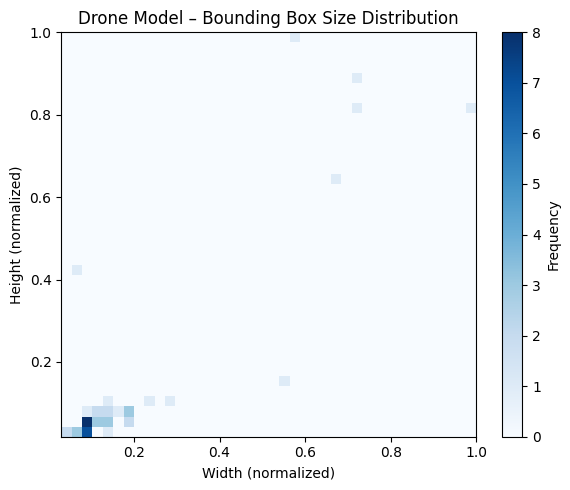

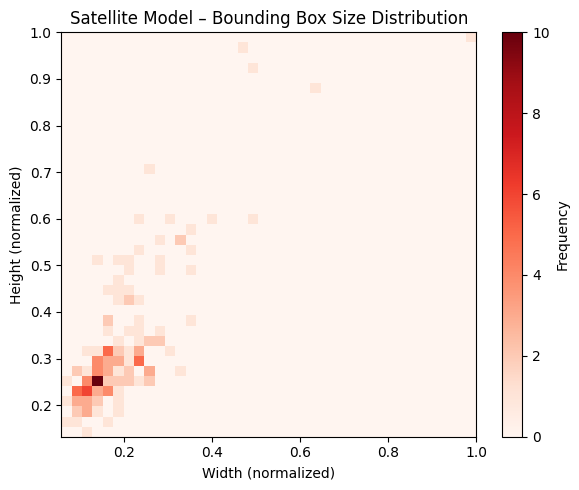

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def box_sizes(model):
    ws, hs = [], []
    results = model.predict(source=TEST_IMAGES, conf=0.25, save=False, verbose=False)
    for r in results:
        if r.boxes is not None:
            for box in r.boxes.xyxy:
                x1, y1, x2, y2 = box.tolist()
                ws.append(x2 - x1)
                hs.append(y2 - y1)
    return np.array(ws), np.array(hs)
# Get box sizes
dw, dh = box_sizes(drone_model)
sw, sh = box_sizes(sat_model)
# ---------------------------
# Drone: Blue colormap
# ---------------------------
plt.figure(figsize=(6,5))
plt.hist2d(dw / dw.max(), dh / dh.max(), bins=40, cmap="Blues")
plt.xlabel("Width (normalized)")
plt.ylabel("Height (normalized)")
plt.title("Drone Model – Bounding Box Size Distribution")
plt.colorbar(label="Frequency")
plt.grid(False)
plt.tight_layout()
plt.show()
# ---------------------------
# Satellite: Red colormap
# ---------------------------
plt.figure(figsize=(6,5))
plt.hist2d(sw / sw.max(), sh / sh.max(), bins=40, cmap="Reds")
plt.xlabel("Width (normalized)")
plt.ylabel("Height (normalized)")
plt.title("Satellite Model – Bounding Box Size Distribution")
plt.colorbar(label="Frequency")
plt.grid(False)
plt.tight_layout()
plt.show()


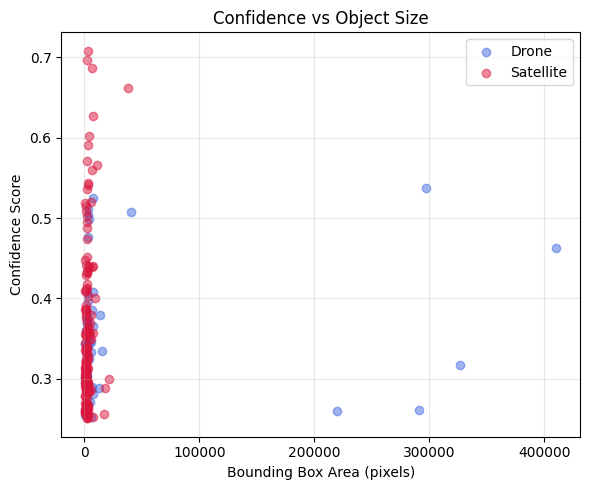

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def conf_area(model):
    areas, confs = [], []
    results = model.predict(source=TEST_IMAGES, conf=0.25, save=False, verbose=False)
    for r in results:
        if r.boxes is not None:
            for box, conf in zip(r.boxes.xyxy, r.boxes.conf):
                x1,y1,x2,y2 = box.tolist()
                area = (x2-x1) * (y2-y1)
                areas.append(area)
                confs.append(float(conf))
    return np.array(areas), np.array(confs)
da, dc = conf_area(drone_model)
sa, sc = conf_area(sat_model)
plt.figure(figsize=(6,5))
plt.scatter(da, dc, alpha=0.5, label="Drone", c="royalblue")
plt.scatter(sa, sc, alpha=0.5, label="Satellite", c="crimson")
plt.xlabel("Bounding Box Area (pixels)")
plt.ylabel("Confidence Score")
plt.title("Confidence vs Object Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

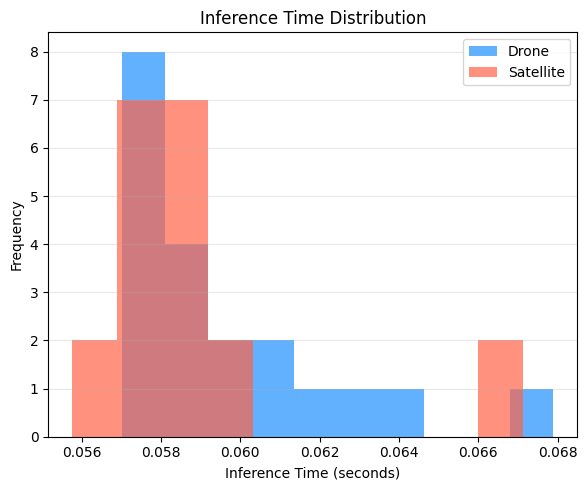

In [ ]:
import time
import matplotlib.pyplot as plt

def inference_times(model):
    times = []
    for _ in range(20):
        t0 = time.time()
        model.predict(source=TEST_IMAGES, conf=0.25, save=False, verbose=False)
        times.append(time.time() - t0)
    return np.array(times)

dt = inference_times(drone_model)
st = inference_times(sat_model)

plt.figure(figsize=(6,5))
plt.hist(dt, bins=10, alpha=0.7, label="Drone", color="dodgerblue")
plt.hist(st, bins=10, alpha=0.7, label="Satellite", color="tomato")
plt.xlabel("Inference Time (seconds)")
plt.ylabel("Frequency")
plt.title("Inference Time Distribution")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


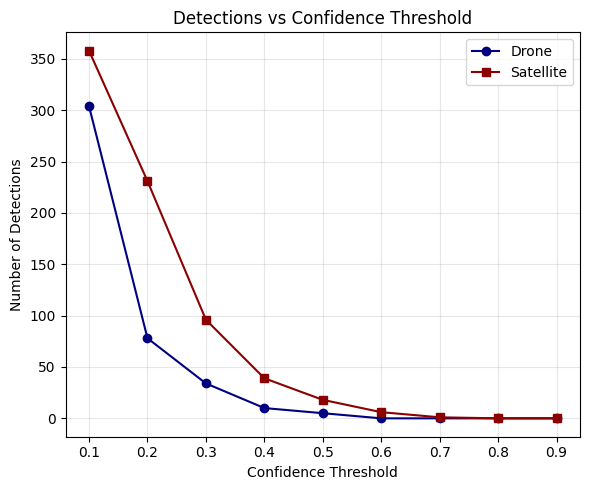

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.linspace(0.1, 0.9, 9)
d_counts, s_counts = [], []

for t in thresholds:
    d = drone_model.predict(source=TEST_IMAGES, conf=t, save=False, verbose=False)
    s = sat_model.predict(source=TEST_IMAGES, conf=t, save=False, verbose=False)
    d_counts.append(sum(len(r.boxes) for r in d if r.boxes is not None))
    s_counts.append(sum(len(r.boxes) for r in s if r.boxes is not None))

plt.figure(figsize=(6,5))
plt.plot(thresholds, d_counts, marker="o", label="Drone", color="navy")
plt.plot(thresholds, s_counts, marker="s", label="Satellite", color="darkred")
plt.xlabel("Confidence Threshold")
plt.ylabel("Number of Detections")
plt.title("Detections vs Confidence Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


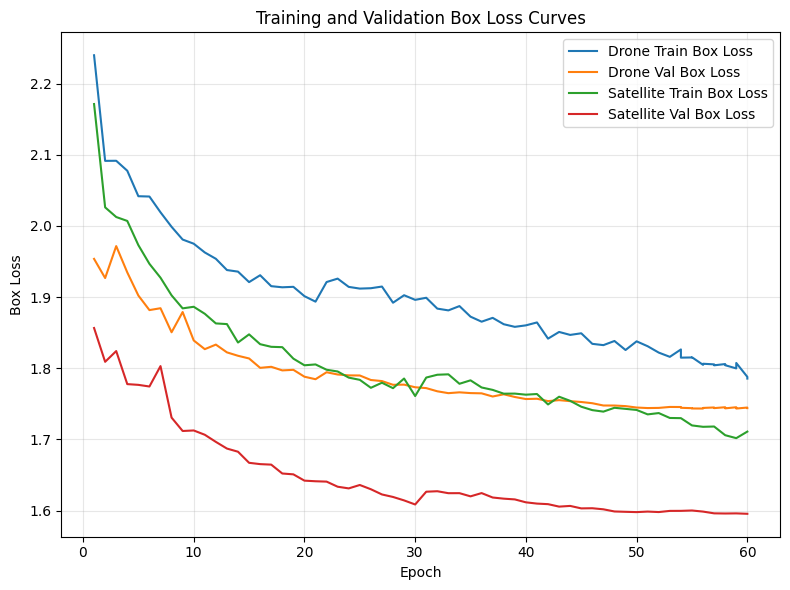

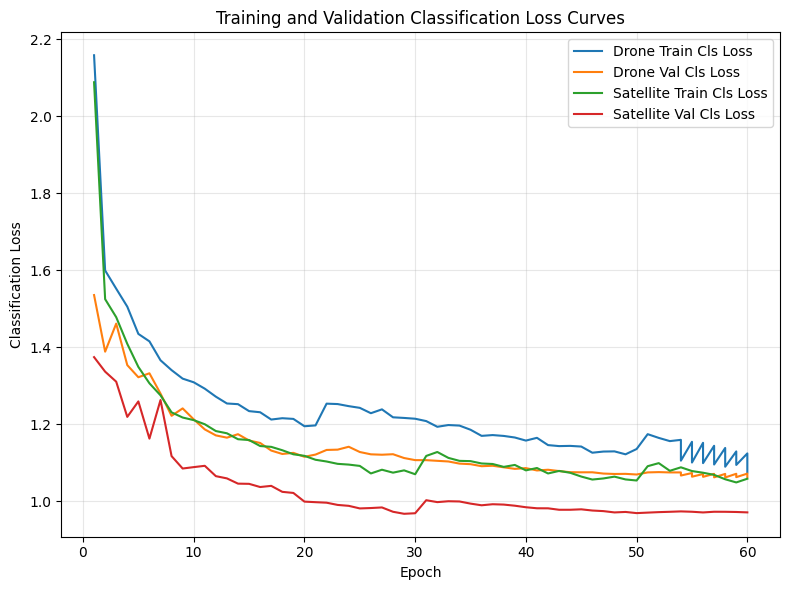

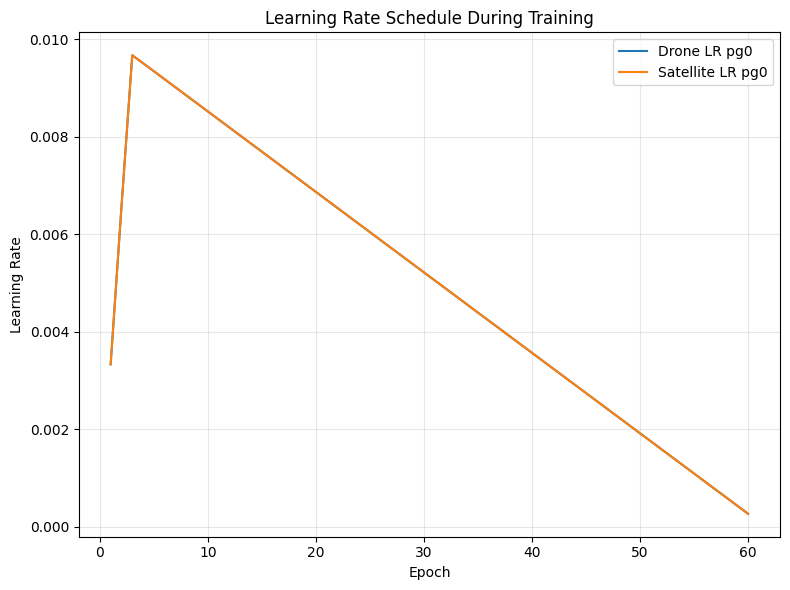

All 4 training-based figures generated and saved.


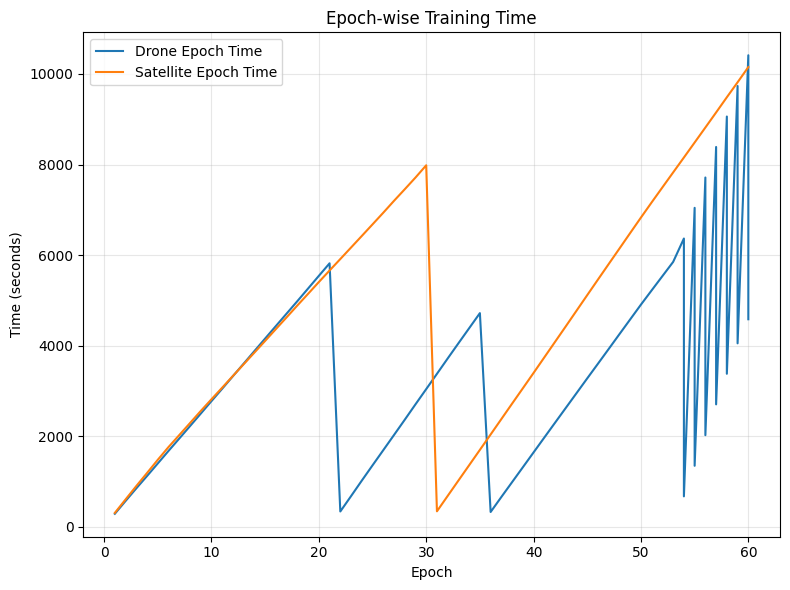

In [4]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
drone_df = pd.read_csv(DRONE_CSV)
sat_df   = pd.read_csv(SAT_CSV)
# ============================================================
# GRAPH 1 — Training vs Validation Box Loss
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(drone_df["epoch"], drone_df["train/box_loss"], label="Drone Train Box Loss")
plt.plot(drone_df["epoch"], drone_df["val/box_loss"],   label="Drone Val Box Loss")
plt.plot(sat_df["epoch"],   sat_df["train/box_loss"],   label="Satellite Train Box Loss")
plt.plot(sat_df["epoch"],   sat_df["val/box_loss"],     label="Satellite Val Box Loss")
plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.title("Training and Validation Box Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Fig_Box_Loss_Curves.png", dpi=300)
plt.show()
# ============================================================
# GRAPH 2 — Training vs Validation Classification Loss
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(drone_df["epoch"], drone_df["train/cls_loss"], label="Drone Train Cls Loss")
plt.plot(drone_df["epoch"], drone_df["val/cls_loss"],   label="Drone Val Cls Loss")
plt.plot(sat_df["epoch"],   sat_df["train/cls_loss"],   label="Satellite Train Cls Loss")
plt.plot(sat_df["epoch"],   sat_df["val/cls_loss"],     label="Satellite Val Cls Loss")
plt.xlabel("Epoch")
plt.ylabel("Classification Loss")
plt.title("Training and Validation Classification Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Fig_Cls_Loss_Curves.png", dpi=300)
plt.show()
# ============================================================
# GRAPH 3 — Learning Rate Schedule
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(drone_df["epoch"], drone_df["lr/pg0"], label="Drone LR pg0")
plt.plot(sat_df["epoch"],   sat_df["lr/pg0"],   label="Satellite LR pg0")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule During Training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Fig_Learning_Rate_Schedule.png", dpi=300)
plt.show()
# ============================================================
# GRAPH 4 — Epoch Time Distribution
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(drone_df["epoch"], drone_df["time"], label="Drone Epoch Time")
plt.plot(sat_df["epoch"],   sat_df["time"],   label="Satellite Epoch Time")
plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.title("Epoch-wise Training Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Fig_Epoch_Time.png", dpi=300)
plt.show
print("All 4 training-based figures generated and saved.")